# 02 — Simplicial Complexes

In Notebook 01 we studied metric spaces and point clouds. We now introduce one of the central combinatorial objects in Topological Data Analysis: the **simplicial complex**.

Simplicial complexes let us build spaces from simple pieces: vertices, edges, triangles, tetrahedra, and their higher-dimensional analogues.

### Learning goals

By the end of this notebook, you should be able to:

- define simplices, faces, and abstract simplicial complexes;
- check the closure condition computationally;
- compute dimensions and simplex counts;
- construct full simplices and their boundaries;
- view graphs as 1-dimensional simplicial complexes;
- compute skeletons;
- visualize small examples;
- understand how metric data will later lead to simplicial complexes.

We will build the basic machinery ourselves before using GUDHI.


## 1. Simplices

A **$k$-simplex** is the basic $k$-dimensional building block of a simplicial complex.

A $k$-simplex has exactly

$$
k+1
$$

vertices.

Thus:

| Dimension | Simplex | Name |
|---|---|---|
| $0$ | one vertex | vertex |
| $1$ | two vertices | edge |
| $2$ | three vertices | triangle |
| $3$ | four vertices | tetrahedron |

For example,

$$
\sigma=\{a,b,c\}
$$

is a $2$-simplex.

Its dimension is

$$
\dim(\sigma)=|\sigma|-1=2.
$$

### Example

$$
\{a,b\}
$$

is a $1$-simplex.


## 2. Faces

Let

$$
\sigma=\{v_0,\ldots,v_k\}
$$

be a simplex.

A **face** of $\sigma$ is any nonempty subset of its vertices.

For the triangle

$$
\sigma=\{a,b,c\},
$$

the faces are

$$
\{a\},\{b\},\{c\},
$$

$$
\{a,b\},\{a,c\},\{b,c\},
$$

and

$$
\{a,b,c\}.
$$

A $k$-simplex has

$$
2^{k+1}-1
$$

nonempty faces.

### Pseudocode

```text
INPUT:
    simplex sigma

INITIALIZE:
    faces = empty collection

FOR every nonempty subset F of sigma:
    add F to faces

RETURN faces
```


In [1]:
from itertools import combinations

def simplex_faces(simplex):
    """Return all nonempty faces of a simplex."""
    vertices = tuple(simplex)
    faces = set()

    for r in range(1, len(vertices) + 1):
        for face in combinations(vertices, r):
            faces.add(frozenset(face))

    return faces

triangle = frozenset({"a", "b", "c"})
simplex_faces(triangle)


{frozenset({'a', 'b'}),
 frozenset({'c'}),
 frozenset({'a'}),
 frozenset({'a', 'c'}),
 frozenset({'b'}),
 frozenset({'b', 'c'}),
 frozenset({'a', 'b', 'c'})}

## 3. Abstract simplicial complexes

An **abstract simplicial complex** is a collection $K$ of finite nonempty sets satisfying the closure condition:

$$
\sigma\in K
\quad\Longrightarrow\quad
\tau\in K
$$

for every nonempty subset

$$
\tau\subseteq\sigma.
$$

In words:

> Whenever a simplex is present, all of its nonempty faces must also be present.

### Example

$$
K=
\{
\{a\},\{b\},\{c\},
\{a,b\},\{b,c\}
\}
$$

is a simplicial complex.

### Non-example

$$
K=
\{
\{a\},\{b\},\{c\},
\{a,b,c\}
\}
$$

is not a simplicial complex because its edges are missing.

This closure condition is the fundamental combinatorial rule.


### Pseudocode: checking a simplicial complex

```text
INPUT:
    collection K of simplices

FOR every simplex sigma in K:
    FOR every nonempty face tau of sigma:
        IF tau is not in K:
            return False

RETURN True
```


In [2]:
def is_simplicial_complex(complex_):
    complex_ = {frozenset(s) for s in complex_ if len(s) > 0}

    for simplex in complex_:
        for face in simplex_faces(simplex):
            if face not in complex_:
                return False

    return True

K_good = {
    frozenset({"a"}), frozenset({"b"}), frozenset({"c"}),
    frozenset({"a", "b"}), frozenset({"b", "c"})
}

K_bad = {
    frozenset({"a"}), frozenset({"b"}), frozenset({"c"}),
    frozenset({"a", "b", "c"})
}

print("K_good:", is_simplicial_complex(K_good))
print("K_bad:", is_simplicial_complex(K_bad))


K_good: True
K_bad: False


In [3]:
def find_missing_face(complex_):
    complex_ = {frozenset(s) for s in complex_ if len(s) > 0}

    for simplex in complex_:
        for face in simplex_faces(simplex):
            if face not in complex_:
                return face

    return None

find_missing_face(K_bad)


frozenset({'a', 'b'})

The second function gives more information than a Boolean test: it identifies a missing face.

This is a useful computational habit throughout the repository:

> When a mathematical condition fails, make the program exhibit a concrete witness to the failure.


## 4. Dimension

For a nonempty simplex,

$$
\dim(\sigma)=|\sigma|-1.
$$

The dimension of a simplicial complex is

$$
\dim(K)=\max_{\sigma\in K}\dim(\sigma).
$$

For example, if $K$ contains vertices, edges, and one triangle, then

$$
\dim(K)=2.
$$

### Pseudocode

```text
INPUT:
    simplex sigma

RETURN:
    number of vertices in sigma minus 1
```


In [4]:
def simplex_dimension(simplex):
    simplex = frozenset(simplex)
    if not simplex:
        raise ValueError("The empty set is not treated as a simplex here.")
    return len(simplex) - 1

def complex_dimension(complex_):
    return max(simplex_dimension(s) for s in complex_)

print(simplex_dimension({"a", "b", "c"}))
print(complex_dimension(K_good))


2
1


## 5. The full simplex

Given a finite vertex set

$$
V=\{v_0,\ldots,v_k\},
$$

the **full simplex** on $V$ contains every nonempty subset of $V$.

For three vertices,

$$
\{a,b,c\},
$$

the full simplex contains three vertices, three edges, and one triangle:

$$
3+3+1=7
$$

simplices in total.

### Pseudocode

```text
INPUT:
    vertex set V

INITIALIZE:
    K = empty collection

FOR every nonempty subset sigma of V:
    add sigma to K

RETURN K
```


In [5]:
def full_simplex(vertices):
    vertices = tuple(vertices)
    complex_ = set()

    for r in range(1, len(vertices) + 1):
        for simplex in combinations(vertices, r):
            complex_.add(frozenset(simplex))

    return complex_

filled_triangle = full_simplex(["a", "b", "c"])

print("Number of simplices:", len(filled_triangle))
print("Dimension:", complex_dimension(filled_triangle))
print("Valid complex:", is_simplicial_complex(filled_triangle))


Number of simplices: 7
Dimension: 2
Valid complex: True


## 6. Boundary of a simplex

The **boundary** of a simplex consists of all of its proper faces.

For a triangle,

$$
\partial\{a,b,c\}
=
\{
\{a\},\{b\},\{c\},
\{a,b\},\{a,c\},\{b,c\}
\}.
$$

Geometrically, this is the triangular loop without its interior.

The boundary of a $k$-simplex is a $(k-1)$-dimensional simplicial complex.

### Pseudocode

```text
INPUT:
    simplex sigma

GENERATE:
    all nonempty faces

REMOVE:
    sigma itself

RETURN:
    remaining faces
```


In [6]:
def simplex_boundary(simplex):
    simplex = frozenset(simplex)
    return {
        face for face in simplex_faces(simplex)
        if face != simplex
    }

triangle_boundary = simplex_boundary({"a", "b", "c"})

print("Boundary:", triangle_boundary)
print("Dimension:", complex_dimension(triangle_boundary))
print("Valid complex:", is_simplicial_complex(triangle_boundary))


Boundary: {frozenset({'b', 'a'}), frozenset({'c'}), frozenset({'c', 'a'}), frozenset({'a'}), frozenset({'b'}), frozenset({'b', 'c'})}
Dimension: 1
Valid complex: True


The distinction is important:

### Filled triangle

$$
\Delta^2
$$

contains the $2$-simplex.

### Triangle boundary

$$
\partial\Delta^2
$$

contains only the proper faces.

They have the same vertices and edges, but they are different simplicial complexes. Later, homology will detect an important topological difference between them.


## 7. Graphs as simplicial complexes

Every simple graph can be viewed as a **1-dimensional simplicial complex**.

Given a graph $G=(V,E)$, take:

$$
K=V\cup E,
$$

where each vertex is a $0$-simplex and each edge is a $1$-simplex.

For

```text
a --- b --- c
```

we get

$$
K=
\{
\{a\},\{b\},\{c\},
\{a,b\},\{b,c\}
\}.
$$

The graph automatically satisfies the closure condition because every edge contains its endpoint vertices.


In [7]:
import networkx as nx

G = nx.Graph()
G.add_edges_from([
    ("a", "b"),
    ("b", "c"),
    ("c", "d"),
])

def graph_to_simplicial_complex(G):
    complex_ = {frozenset({v}) for v in G.nodes}
    complex_.update(frozenset(e) for e in G.edges)
    return complex_

K_graph = graph_to_simplicial_complex(G)

print(K_graph)
print("Dimension:", complex_dimension(K_graph))
print("Valid complex:", is_simplicial_complex(K_graph))


{frozenset({'b', 'a'}), frozenset({'c'}), frozenset({'c', 'd'}), frozenset({'d'}), frozenset({'a'}), frozenset({'b'}), frozenset({'b', 'c'})}
Dimension: 1
Valid complex: True


## 8. Skeletons

The **$k$-skeleton** of a simplicial complex $K$, written $K^{(k)}$, is the subcomplex consisting of all simplices of dimension at most $k$.

For a filled triangle:

$$
K^{(0)}
$$

contains only vertices,

$$
K^{(1)}
$$

contains vertices and edges, and

$$
K^{(2)}
$$

is the entire filled triangle.

Thus

$$
K^{(0)}\subseteq K^{(1)}\subseteq K^{(2)}.
$$

### Pseudocode

```text
INPUT:
    simplicial complex K
    integer k

SELECT:
    every simplex sigma with dimension(sigma) <= k

RETURN:
    selected simplices
```


In [8]:
def skeleton(complex_, k):
    return {
        frozenset(s)
        for s in complex_
        if simplex_dimension(s) <= k
    }

K = full_simplex(["a", "b", "c"])

for k in range(3):
    print(f"{k}-skeleton:", skeleton(K, k))


0-skeleton: {frozenset({'a'}), frozenset({'b'}), frozenset({'c'})}
1-skeleton: {frozenset({'b', 'a'}), frozenset({'c'}), frozenset({'c', 'a'}), frozenset({'a'}), frozenset({'b'}), frozenset({'b', 'c'})}
2-skeleton: {frozenset({'b', 'c', 'a'}), frozenset({'b', 'a'}), frozenset({'c'}), frozenset({'c', 'a'}), frozenset({'a'}), frozenset({'b'}), frozenset({'b', 'c'})}


## 9. Counting simplices by dimension

If $f_k$ denotes the number of $k$-simplices, then

$$
(f_0,f_1,f_2,\ldots)
$$

is called the **$f$-vector** of the complex.

### Pseudocode

```text
INPUT:
    simplicial complex K

INITIALIZE:
    counter

FOR every simplex sigma:
    compute dim(sigma)
    increase the corresponding counter

RETURN:
    counts by dimension
```


In [9]:
from collections import Counter

def simplex_counts(complex_):
    counts = Counter(simplex_dimension(s) for s in complex_)
    return dict(sorted(counts.items()))

print("Filled triangle:", simplex_counts(filled_triangle))
print("Triangle boundary:", simplex_counts(triangle_boundary))
print("Graph:", simplex_counts(K_graph))


Filled triangle: {0: 3, 1: 3, 2: 1}
Triangle boundary: {0: 3, 1: 3}
Graph: {0: 4, 1: 3}


For the filled triangle,

$$
f_0=3,\qquad f_1=3,\qquad f_2=1.
$$

For the triangle boundary,

$$
f_0=3,\qquad f_1=3.
$$

For the full tetrahedron, we would have

$$
f_0=4,\qquad f_1=6,\qquad f_2=4,\qquad f_3=1.
$$


## 10. Visualizing a 1-dimensional complex

A graph gives us a simple visualization of a 1-dimensional simplicial complex.


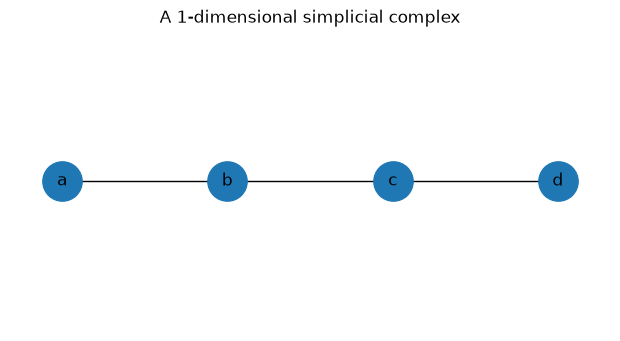

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))

pos = {
    "a": (0, 0),
    "b": (1, 0),
    "c": (2, 0),
    "d": (3, 0),
}

nx.draw(
    G,
    pos=pos,
    with_labels=True,
    node_size=800,
)

plt.title("A 1-dimensional simplicial complex")
plt.axis("equal")
plt.show()


## 11. Visualizing a 2-dimensional simplex

The geometric realization of the abstract simplex

$$
\{a,b,c\}
$$

can be drawn as a filled triangle.


In [11]:
import numpy as np
import matplotlib.pyplot as plt


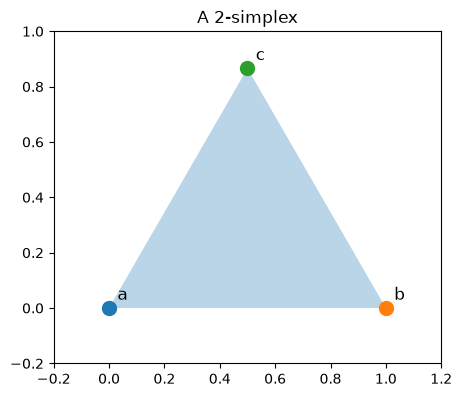

In [12]:
from matplotlib.patches import Polygon

vertices = {
    "a": np.array([0.0, 0.0]),
    "b": np.array([1.0, 0.0]),
    "c": np.array([0.5, np.sqrt(3) / 2]),
}

fig, ax = plt.subplots(figsize=(5, 5))

ax.add_patch(
    Polygon(
        [vertices["a"], vertices["b"], vertices["c"]],
        closed=True,
        alpha=0.3,
    )
)

for name, point in vertices.items():
    ax.scatter(*point, s=100)
    ax.text(point[0] + 0.03, point[1] + 0.03, name, fontsize=12)

ax.set_aspect("equal")
ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.0)
ax.set_title("A 2-simplex")
plt.show()


The **abstract** simplex records combinatorial incidence:

$$
\{a,b,c\}.
$$

The **geometric realization** places those vertices in Euclidean space and fills in their convex hull.

The particular coordinates are not part of the abstract simplicial complex. The combinatorial structure is what matters for the constructions we will use later.


## 12. A larger example: the boundary of a tetrahedron

For four vertices

$$
a,b,c,d,
$$

the full $3$-simplex is

$$
\{a,b,c,d\}.
$$

Its boundary has:

$$
f_0=4,\qquad f_1=6,\qquad f_2=4.
$$

There is no $3$-simplex in the boundary.


In [13]:
tetrahedron = full_simplex(["a", "b", "c", "d"])
tetrahedron_boundary = simplex_boundary(["a", "b", "c", "d"])

print("Full tetrahedron:", simplex_counts(tetrahedron))
print("Boundary:", simplex_counts(tetrahedron_boundary))
print("Boundary dimension:", complex_dimension(tetrahedron_boundary))


Full tetrahedron: {0: 4, 1: 6, 2: 4, 3: 1}
Boundary: {0: 4, 1: 6, 2: 4}
Boundary dimension: 2


## 13. From metric data to simplicial complexes

This is the bridge to TDA.

Suppose we start with a point cloud

$$
X=\{x_1,\ldots,x_n\}
$$

and a metric $d$.

At a scale $\varepsilon$, we can connect two points whenever

$$
d(x_i,x_j)\leq\varepsilon.
$$

This produces a graph.

We can then fill higher-dimensional simplices whenever several points are mutually close. That idea leads to the **Vietoris–Rips complex**.

We will study that construction later. For now, the important conceptual chain is

$$
\boxed{
\text{metric data}
\longrightarrow
\text{simplicial complex}
}
$$

The metric-space notebook gave us the first object. This notebook gives us the second.


## 14. Summary

A **$k$-simplex** has

$$
k+1
$$

vertices and dimension

$$
k=|\sigma|-1.
$$

A **face** is a nonempty subset of the vertices of a simplex.

An **abstract simplicial complex** is a collection of simplices closed under taking nonempty faces:

$$
\sigma\in K
\Longrightarrow
\tau\in K
\quad
\text{for every nonempty }\tau\subseteq\sigma.
$$

The dimension of a complex is

$$
\dim(K)=\max_{\sigma\in K}\dim(\sigma).
$$

The **full simplex** contains every nonempty subset of its vertex set.

The **boundary** contains all proper faces.

The **$k$-skeleton** contains all simplices of dimension at most $k$.

A graph can be regarded as a 1-dimensional simplicial complex.

The main computational principle is:

$$
\boxed{
\text{construct}
\longrightarrow
\text{validate}
\longrightarrow
\text{inspect}
\longrightarrow
\text{visualize}
}
$$


## Exercises

### Exercise 1 — Build a complex

Let

$$
V=\{a,b,c,d\}.
$$

Construct the complex containing all four vertices and the edges

$$
\{a,b\},\quad
\{b,c\},\quad
\{c,d\},\quad
\{d,a\}.
$$

Verify that it is a simplicial complex and compute its dimension.

### Exercise 2 — Find a missing face

Start with

$$
\{
\{a\},\{b\},\{c\},
\{a,b\},\{b,c\},
\{a,b,c\}
\}.
$$

Remove one face and use `find_missing_face` to identify the violation.

### Exercise 3 — Boundary of a tetrahedron

Construct the boundary of

$$
\{a,b,c,d\}
$$

and verify

$$
f_0=4,\qquad f_1=6,\qquad f_2=4.
$$

What changes if you add the tetrahedron itself?

### Exercise 4 — Skeletons

For the full tetrahedron, compute

$$
K^{(0)},\qquad K^{(1)},\qquad K^{(2)},\qquad K^{(3)}.
$$

How many simplices occur in each?

### Exercise 5 — Graphs

Choose a graph with at least five vertices and convert it into a 1-dimensional simplicial complex.

Verify:

1. every edge has its endpoints;
2. the collection is a simplicial complex;
3. its dimension is $1$.

### Exercise 6 — Point clouds

Return to the circle point cloud from Notebook 01.

Choose a scale $\varepsilon$ and construct the graph whose vertices are the sampled points and whose edges satisfy

$$
d(x_i,x_j)\leq\varepsilon.
$$

Plot the graph.

Do not construct higher-dimensional simplices yet. We will build on this experiment when we introduce Vietoris–Rips complexes.


## References

1. M. A. Armstrong, *Basic Topology*, Undergraduate Texts in Mathematics, Springer.

2. F. Chazal and B. Michel, *An Introduction to Topological Data Analysis: Fundamental and Practical Aspects for Data Scientists*, *Frontiers in Artificial Intelligence* 4 (2021), 667963.  
   https://doi.org/10.3389/frai.2021.667963

3. H. Edelsbrunner and J. Harer, *Computational Topology: An Introduction*, American Mathematical Society, 2010.
